# Import modules

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import sys
sys.path.insert(0, '../')
from pysheds.grid import Grid
import seaborn as sns

%matplotlib inline

In [3]:
sns.set()
sns.set_palette('husl', 8)

# Create a flow direction grid from a raster

Data from USGS hydrosheds project: https://hydrosheds.cr.usgs.gov/datadownload.php

In [4]:
FILE = '../data/dem.tif'
grid = Grid.from_raster(FILE)
dem = grid.read_raster(FILE)

# Specify flow direction values

In [5]:
         #N    NE    E    SE    S    SW    W    NW
dirmap = (64,  128,  1,   2,    4,   8,    16,  32)

# Delineate catchment

In [6]:
# Heal terrain
dem_filled = grid.fill_pits(dem)
dem_flooded = grid.fill_depressions(dem_filled)
dem_conditioned = grid.resolve_flats(dem_flooded)

# Generate Flow Direction
fdir = grid.flowdir(dem_conditioned, dirmap=dirmap)

In [7]:
# Specify pour point
x, y = -97.294167, 32.73750

# Delineate the catchment
catch = grid.catchment(x=x, y=y, fdir=fdir, dirmap=dirmap, 
                       recursionlimit=15000, xytype='label')

In [8]:
# Clip the bounding box to the catchment
grid.clip_to(catch)

# Get flow accumulation

In [9]:
fdir_view = grid.view(fdir)
catch_view = grid.view(catch)

# Compute accumulation on the clipped grid
acc = grid.accumulation(fdir=fdir_view, dirmap=dirmap)

# Extract river network

In [10]:
# Create mask for threshold
river_mask = (acc > 200)

# Extract network as GeoJSON
branches = grid.extract_river_network(fdir=fdir_view, mask=river_mask)

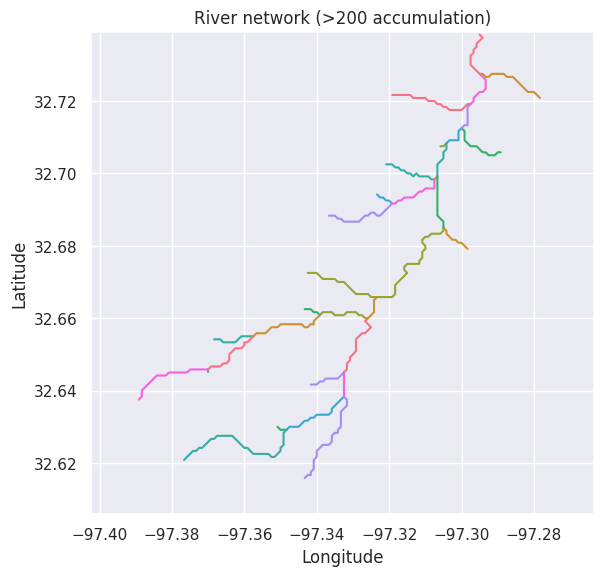

In [11]:
fig, ax = plt.subplots(figsize=(6.5,6.5))

plt.grid('on', zorder=0)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('River network (>200 accumulation)')

# Use grid.extent for the clipped area
plt.xlim(grid.extent[0], grid.extent[1])
plt.ylim(grid.extent[2], grid.extent[3])
ax.set_aspect('equal')

for branch in branches['features']:
    line = np.asarray(branch['geometry']['coordinates'])
    plt.plot(line[:, 0], line[:, 1])

In [12]:
river_mask_50 = (acc > 50)
branches_50 = grid.extract_river_network(fdir=fdir_view, mask=river_mask_50)

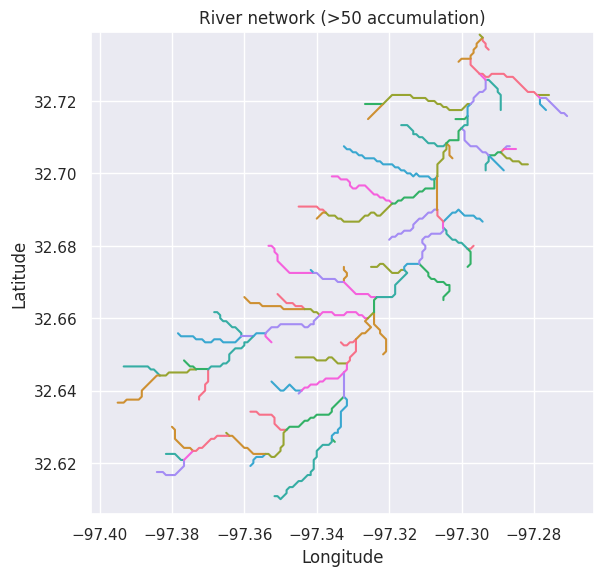

In [13]:
fig, ax = plt.subplots(figsize=(6.5,6.5))

plt.grid('on', zorder=0)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('River network (>50 accumulation)')
plt.xlim(grid.extent[0], grid.extent[1])
plt.ylim(grid.extent[2], grid.extent[3])
ax.set_aspect('equal')

for branch in branches_50['features']:
    line = np.asarray(branch['geometry']['coordinates'])
    plt.plot(line[:, 0], line[:, 1])

# Save the high-detail network
plt.savefig('river_network_50.png', bbox_inches='tight')

In [14]:
river_mask_2 = (acc > 2)
branches_2 = grid.extract_river_network(fdir=fdir_view, mask=river_mask_2)

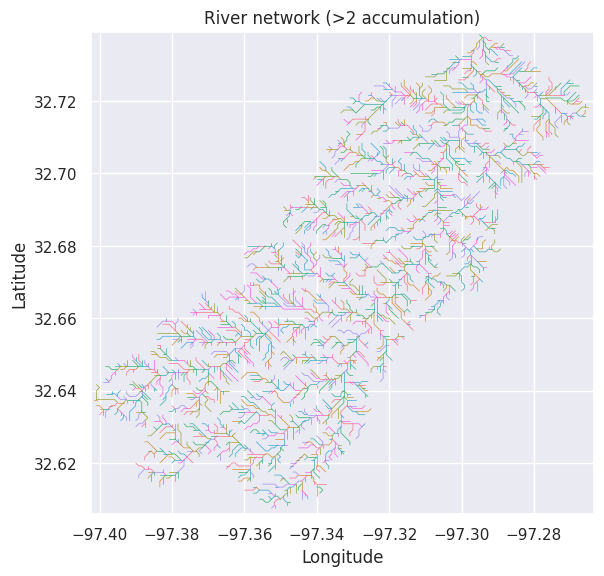

In [15]:
fig, ax = plt.subplots(figsize=(6.5,6.5))

plt.grid('on', zorder=0)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('River network (>2 accumulation)')
plt.xlim(grid.extent[0], grid.extent[1])
plt.ylim(grid.extent[2], grid.extent[3])
ax.set_aspect('equal')

for branch in branches_2['features']:
    line = np.asarray(branch['geometry']['coordinates'])
    # Use a thinner line for the high-density network
    plt.plot(line[:, 0], line[:, 1], linewidth=0.5)